In [ ]:
!pip install metatrader5

ERROR: Could not find a version that satisfies the requirement metatrader5 (from versions: none)
ERROR: No matching distribution found for metatrader5


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install tqdm

In [ ]:
import os
import shutil

# ==== CONFIGURATION ====
SOURCE_DIR = "/content/drive/MyDrive/Fashion_Image"            # your main dataset directory
DEST_DIR = "Dataset_Small"        # new folder where cloned data will go
MAX_SIZE_BYTES = 3.5 * 1024**3    # 3.5 GB in bytes
IMAGES_PER_CLASS = 5              # number of images per class

# ==== SCRIPT ====
def get_dir_size(path):
    """Return total size (bytes) of all files under a directory."""
    total = 0
    for dirpath, _, filenames in os.walk(path):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            if os.path.isfile(fp):
                total += os.path.getsize(fp)
    return total

def copy_limited_dataset(src_root, dest_root):
    os.makedirs(dest_root, exist_ok=True)
    total_copied_size = 0

    for subfolder in sorted(os.listdir(src_root)):
        subfolder_path = os.path.join(src_root, subfolder)
        if not os.path.isdir(subfolder_path):
            continue

        # Iterate through classes in each New_folder_X
        for class_name in sorted(os.listdir(subfolder_path)):
            class_path = os.path.join(subfolder_path, class_name)
            if not os.path.isdir(class_path):
                continue

            dest_class_path = os.path.join(dest_root, subfolder, class_name)
            os.makedirs(dest_class_path, exist_ok=True)

            images = sorted(
                [f for f in os.listdir(class_path)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif'))]
            )

            for img_name in images[:IMAGES_PER_CLASS]:
                src_img_path = os.path.join(class_path, img_name)
                dest_img_path = os.path.join(dest_class_path, img_name)

                img_size = os.path.getsize(src_img_path)

                # Check if copying exceeds max size
                if total_copied_size + img_size > MAX_SIZE_BYTES:
                    print(f"⚠️  Stopping: size limit of {MAX_SIZE_BYTES/1024**3:.2f} GB reached.")
                    return

                shutil.copy2(src_img_path, dest_img_path)
                total_copied_size += img_size

                print(f"Copied: {src_img_path} → {dest_img_path}")

    print(f"\n✅ Done! Total copied size: {total_copied_size / 1024**3:.2f} GB")

# ==== RUN ====
if __name__ == "__main__":
    copy_limited_dataset(SOURCE_DIR, DEST_DIR)

In [ ]:
import os
import shutil
from concurrent.futures import ThreadPoolExecutor, as_completed
import threading
from tqdm import tqdm # Import tqdm

# ==== CONFIGURATION ====
SOURCE_DIR = "/content/drive/MyDrive/Fashion_Image"            # your main dataset directory
DEST_DIR = "Dataset_Small_Multi"      # new folder where cloned data will go
MAX_SIZE_BYTES = 3.5 * 1024**3    # 3.5 GB in bytes
IMAGES_PER_CLASS = 5              # number of images per class
MAX_WORKERS = 8                   # Adjust based on your system (e.g., number of cores * 2)

# ==== GLOBAL STATE & LOCKS ====
total_copied_size = 0
size_lock = threading.Lock()
stop_event = threading.Event()

# ==== SCRIPT ====
def copy_file(src_path, dest_path):
    """Copies a single file and updates the total size securely."""
    global total_copied_size

    if stop_event.is_set():
        return False  # Indicate that the file was not copied

    try:
        img_size = os.path.getsize(src_path)

        # Check if copying exceeds max size *before* the copy operation starts
        with size_lock:
            if total_copied_size + img_size > MAX_SIZE_BYTES:
                if not stop_event.is_set(): # Only print and set event once
                    print(f"\n⚠️  Stopping: size limit of {MAX_SIZE_BYTES/1024**3:.2f} GB reached.")
                    stop_event.set()
                return False

            # If the size is within limit, copy the file
            shutil.copy2(src_path, dest_path)
            total_copied_size += img_size

        # The print statement for individual files is removed here to prevent
        # spamming the console and interfering with the tqdm bar.
        # It's better to show aggregate progress.
        return True

    except Exception as e:
        print(f"Error copying {src_path}: {e}")
        return False

def copy_limited_dataset(src_root, dest_root):
    os.makedirs(dest_root, exist_ok=True)
    files_to_copy = []

    # --- 1. Collect all file paths and their destinations ---
    # This phase remains serial as before.
    print("Scanning dataset structure and collecting file list...")
    for subfolder in sorted(os.listdir(src_root)):
        if stop_event.is_set(): break
        subfolder_path = os.path.join(src_root, subfolder)
        if not os.path.isdir(subfolder_path): continue

        for class_name in sorted(os.listdir(subfolder_path)):
            if stop_event.is_set(): break
            class_path = os.path.join(subfolder_path, class_name)
            if not os.path.isdir(class_path): continue

            dest_class_path = os.path.join(dest_root, subfolder, class_name)
            os.makedirs(dest_class_path, exist_ok=True)

            images = sorted(
                [f for f in os.listdir(class_path)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif'))]
            )

            for img_name in images[:IMAGES_PER_CLASS]:
                src_img_path = os.path.join(class_path, img_name)
                dest_img_path = os.path.join(dest_class_path, img_name)
                files_to_copy.append((src_img_path, dest_img_path))

    total_files = len(files_to_copy)
    print(f"Found {total_files} files to potentially copy.")

    # --- 2. Execute copying using a ThreadPoolExecutor with tqdm ---
    futures = []

    # Initialize the progress bar with the total number of files
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor, \
         tqdm(total=total_files, desc="Copying Files", unit="file") as pbar:

        for src, dest in files_to_copy:
            if stop_event.is_set():
                break # Stop submitting new tasks

            future = executor.submit(copy_file, src, dest)
            futures.append(future)

        # Iterate over completed futures to update the progress bar
        for future in as_completed(futures):
            # The result() call ensures we catch any exceptions from the thread
            result = future.result()

            # If the stop_event was set, we might need to adjust the progress bar
            # if we break out of the loop early.

            # We only update the progress bar if the task was *executed*
            # (regardless of whether the file was copied or skipped due to size limit)
            pbar.update(1)

            # Check if the overall copying process should stop
            if stop_event.is_set():
                # Cancel any pending futures that haven't started yet
                for f in futures:
                    f.cancel()
                break # Exit the as_completed loop

    final_copied_size = total_copied_size
    print(f"\n✅ Done! Total copied size: {final_copied_size / 1024**3:.2f} GB")

# ==== RUN ====
if __name__ == "__main__":
    copy_limited_dataset(SOURCE_DIR, DEST_DIR)

Scanning dataset structure and collecting file list...
Found 28039 files to potentially copy.


Copying Files: 100%|██████████| 28039/28039 [3:46:36<00:00,  2.06file/s]


✅ Done! Total copied size: 2.65 GB


In [ ]:
!zip -r Dataset_Small.zip Dataset_Small

	zip warning: name not matched: Dataset_Small

zip error: Nothing to do! (try: zip -r Dataset_Small.zip . -i Dataset_Small)


In [ ]:
!zip -r Dataset_Small_Multi.zip Dataset_Small_Multi

Streaming output truncated to the last 5000 lines.
  adding: Dataset_Small_Multi/NEW_FOLDER_M/Mixed_Stripe_Shorts/img_00000005.jpg (deflated 2%)
  adding: Dataset_Small_Multi/NEW_FOLDER_M/Mixed_Stripe_Shorts/img_00000001.jpg (deflated 4%)
  adding: Dataset_Small_Multi/NEW_FOLDER_M/Mixed_Stripe_Shorts/img_00000004.jpg (deflated 12%)
  adding: Dataset_Small_Multi/NEW_FOLDER_M/Mixed_Stripe_Shorts/img_00000002.jpg (deflated 5%)
  adding: Dataset_Small_Multi/NEW_FOLDER_M/Mixed_Stripe_Shorts/img_00000003.jpg (deflated 4%)
  adding: Dataset_Small_Multi/NEW_FOLDER_M/Micro-Stripe_V-Neck_Tee/ (stored 0%)
  adding: Dataset_Small_Multi/NEW_FOLDER_M/Micro-Stripe_V-Neck_Tee/img_00000005.jpg (deflated 2%)
  adding: Dataset_Small_Multi/NEW_FOLDER_M/Micro-Stripe_V-Neck_Tee/img_00000001.jpg (deflated 6%)
  adding: Dataset_Small_Multi/NEW_FOLDER_M/Micro-Stripe_V-Neck_Tee/img_00000004.jpg (deflated 2%)
  adding: Dataset_Small_Multi/NEW_FOLDER_M/Micro-Stripe_V-Neck_Tee/img_00000002.jpg (deflated 35%)
  add

In [ ]:
!mv /content/Dataset_Small_Multi.zip /content/drive/MyDrive/

In [ ]:
!cp /content/drive/MyDrive/Dataset_Small_Multi.zip /content/


In [ ]:
!unzip /content/Dataset_Small_Multi.zip

Streaming output truncated to the last 5000 lines.
  inflating: Dataset_Small_Multi/NEW_FOLDER_M/Mixed_Stripe_Shorts/img_00000005.jpg  
  inflating: Dataset_Small_Multi/NEW_FOLDER_M/Mixed_Stripe_Shorts/img_00000001.jpg  
  inflating: Dataset_Small_Multi/NEW_FOLDER_M/Mixed_Stripe_Shorts/img_00000004.jpg  
  inflating: Dataset_Small_Multi/NEW_FOLDER_M/Mixed_Stripe_Shorts/img_00000002.jpg  
  inflating: Dataset_Small_Multi/NEW_FOLDER_M/Mixed_Stripe_Shorts/img_00000003.jpg  
   creating: Dataset_Small_Multi/NEW_FOLDER_M/Micro-Stripe_V-Neck_Tee/
  inflating: Dataset_Small_Multi/NEW_FOLDER_M/Micro-Stripe_V-Neck_Tee/img_00000005.jpg  
  inflating: Dataset_Small_Multi/NEW_FOLDER_M/Micro-Stripe_V-Neck_Tee/img_00000001.jpg  
  inflating: Dataset_Small_Multi/NEW_FOLDER_M/Micro-Stripe_V-Neck_Tee/img_00000004.jpg  
  inflating: Dataset_Small_Multi/NEW_FOLDER_M/Micro-Stripe_V-Neck_Tee/img_00000002.jpg  
  inflating: Dataset_Small_Multi/NEW_FOLDER_M/Micro-Stripe_V-Neck_Tee/img_00000003.jpg  
   creat

In [ ]:
!pip install chromadb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 3.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.8/20.8 MB 119.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.3/103.3 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.3/132.3 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.0/208.0 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 11.7 MB/s 

In [ ]:
# =========================================================
#  local_feature_extraction_to_chroma.py
# =========================================================
import os
from pathlib import Path
from tqdm import tqdm
import cv2
import numpy as np
import torch
import torch.nn as nn
from torchvision import transforms, models

import chromadb
from chromadb.config import Settings

# ------------------- CONFIG -------------------
DATA_DIR = Path("/content/Dataset_Small_Multi")  # <-- put your images here
CHROMA_PATH = Path("./chroma_db")  # <-- where the DB lives
COLLECTION = "fashion"  # name inside Chroma
MODEL_NAME = "resnet50"  # only choice for zero-deps
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ------------------------------------------------
print(f"Using device: {DEVICE}")


# ------------------- 1. FEATURE EXTRACTOR -------------------
class ResNetExtractor:
    def __init__(self, device=DEVICE):
        self.device = torch.device(device)

        # Load ResNet-50, drop the final classification layer
        backbone = models.resnet50(pretrained=True)
        self.model = nn.Sequential(*list(backbone.children())[:-1])
        self.model.to(self.device)
        self.model.eval()

        # Standard ImageNet normalization
        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])

    @torch.no_grad()
    def __call__(self, bgr_img):
        """Input: OpenCV BGR uint8 image → returns L2-normalized np.array"""
        tensor = self.transform(bgr_img).unsqueeze(0).to(self.device)
        feat = self.model(tensor)  # (1, 2048, 1, 1)
        vec = feat.squeeze().cpu().numpy()  # (2048,)
        vec = vec / np.linalg.norm(vec)  # L2 → cosine ready
        return vec


# ------------------- 2. CHROMA SETUP -------------------
def get_or_create_collection():
    client = chromadb.PersistentClient(
        path=str(CHROMA_PATH),
        settings=Settings(anonymized_telemetry=False)
    )
    coll = client.get_or_create_collection(
        name=COLLECTION,
        metadata={"hnsw:space": "cosine"}  # cosine distance = dot-product of L2 vectors
    )
    return coll


# ------------------- 3. MAIN PIPELINE -------------------
def main():
    extractor = ResNetExtractor()
    collection = get_or_create_collection()

    # Gather every image
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}
    image_paths = [p for p in DATA_DIR.rglob("*") if p.suffix.lower() in exts]
    print(f"Found {len(image_paths)} images → embedding…")

    for img_path in tqdm(image_paths, desc="Embedding"):
        img = cv2.imread(str(img_path))
        if img is None:
            continue

        vec = extractor(img)  # (2048,)

        # Unique ID = safe filename (no path separators)
        uid = str(img_path).replace(os.sep, "_")

        meta = {
            "path": str(img_path),
            "category": img_path.parent.name,  # e.g. "tshirts"
            "filename": img_path.name,
        }

        # Upsert (idempotent)
        collection.add(
            ids=[uid],
            embeddings=[vec.tolist()],
            metadatas=[meta],
        )

    print(f"Done! All vectors are stored in {CHROMA_PATH}")


# ------------------- 4. QUICK SEARCH EXAMPLE -------------------
def demo_search(query_image_path):
    """Run after the DB is built to see nearest neighbors."""
    extractor = ResNetExtractor()
    collection = get_or_create_collection()

    q_img = cv2.imread(query_image_path)
    q_vec = extractor(q_img)

    results = collection.query(
        query_embeddings=[q_vec.tolist()],
        n_results=5,
        include=["metadatas", "distances"]
    )

    print("\nTop-5 matches:")
    for meta, dist in zip(results["metadatas"][0], results["distances"][0]):
        print(f"  • {meta['path']}  (dist={dist:.4f})")


# ------------------------------------------------
if __name__ == "__main__":
    import sys

    if len(sys.argv) > 1 and sys.argv[1] == "search":
        # python script.py search path/to/query.jpg
        demo_search(sys.argv[2])
    else:
        main()


Using device: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 187MB/s]


Found 28039 images → embedding…


Embedding: 100%|██████████| 28039/28039 [25:20<00:00, 18.45it/s]

Done! All vectors are stored in chroma_db


In [ ]:
!zip -r chroma_db.zip chroma_db/

updating: chroma_db/ (stored 0%)
  adding: chroma_db/1d8d0631-29e0-44f2-bfae-7fd1571009ce/ (stored 0%)
  adding: chroma_db/1d8d0631-29e0-44f2-bfae-7fd1571009ce/length.bin (deflated 81%)
  adding: chroma_db/1d8d0631-29e0-44f2-bfae-7fd1571009ce/link_lists.bin (deflated 75%)
  adding: chroma_db/1d8d0631-29e0-44f2-bfae-7fd1571009ce/header.bin (deflated 56%)
  adding: chroma_db/1d8d0631-29e0-44f2-bfae-7fd1571009ce/data_level0.bin (deflated 10%)
  adding: chroma_db/1d8d0631-29e0-44f2-bfae-7fd1571009ce/index_metadata.pickle (deflated 85%)
  adding: chroma_db/chroma.sqlite3 (deflated 64%)


In [ ]:
!cp chroma_db.zip /content/drive/MyDrive

In [ ]:
!pip install pinecone

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 587.6/587.6 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.3/259.3 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 7.3 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 25.0
    Uninstalling packaging-25.0:
      Successfully uninstalled packaging-25.0


In [ ]:
# =========================================================
#  feature_extraction_pinecone.py
# =========================================================
import os
from pathlib import Path
from tqdm import tqdm
import cv2
import numpy as np
import torch
import torch.nn as nn
from torchvision import transforms, models

from pinecone import Pinecone, ServerlessSpec  # <-- NEW SDK
from dotenv import load_dotenv

# ------------------- LOAD ENV -------------------
load_dotenv()

# ------------------- CONFIG -------------------
DATA_DIR = Path("/content/Dataset_Small_Multi")
INDEX_NAME = "fashion-index"
DIMENSION = 2048
METRIC = "cosine"
CLOUD = "aws"           # or "gcp", "azure"
REGION = "us-east-1"    # change based on your account
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ------------------- PINECONE SETUP -------------------
PINECONE_API_KEY = os.getenv("PINECONE_API_KEY")
if not PINECONE_API_KEY:
    raise ValueError("PINECONE_API_KEY not found in .env")

# Initialize Pinecone client
pc = Pinecone(api_key=PINECONE_API_KEY)

print(f"Using device: {DEVICE}")
print(f"Pinecone index: {INDEX_NAME} ({CLOUD}/{REGION})")


# ------------------- 1. FEATURE EXTRACTOR -------------------
class ResNetExtractor:
    def __init__(self, device=DEVICE):
        self.device = torch.device(device)
        backbone = models.resnet50(pretrained=True)
        self.model = nn.Sequential(*list(backbone.children())[:-1])
        self.model.to(self.device)
        self.model.eval()

        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])

    @torch.no_grad()
    def __call__(self, bgr_img):
        tensor = self.transform(bgr_img).unsqueeze(0).to(self.device)
        feat = self.model(tensor)
        vec = feat.squeeze().cpu().numpy()
        vec = vec / np.linalg.norm(vec)
        return vec


# ------------------- 2. INDEX SETUP -------------------
def get_or_create_index():
    # List existing indexes
    existing_indexes = [idx["name"] for idx in pc.list_indexes()]

    if INDEX_NAME not in existing_indexes:
        print(f"Creating serverless index '{INDEX_NAME}'...")
        pc.create_index(
            name=INDEX_NAME,
            dimension=DIMENSION,
            metric=METRIC,
            spec=ServerlessSpec(
                cloud=CLOUD,
                region=REGION
            )
        )
        print("Index created. Waiting for readiness...")
        # Wait until ready
        import time
        while True:
            status = pc.describe_index(INDEX_NAME).status
            if status["ready"]:
                print("Index is ready!")
                break
            print("Index not ready yet, waiting 5s...")
            time.sleep(5)
    else:
        print(f"Index '{INDEX_NAME}' already exists.")

    # Connect to index
    index = pc.Index(INDEX_NAME)
    print(f"Index stats: {index.describe_index_stats()}")
    return index


# ------------------- 3. MAIN PIPELINE -------------------
def main():
    extractor = ResNetExtractor()
    index = get_or_create_index()

    exts = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}
    image_paths = [p for p in DATA_DIR.rglob("*") if p.suffix.lower() in exts]
    print(f"Found {len(image_paths)} images → embedding & upserting...")

    batch_size = 32
    batch = []

    for img_path in tqdm(image_paths, desc="Processing"):
        img = cv2.imread(str(img_path))
        if img is None:
            continue

        vec = extractor(img)
        uid = str(img_path).replace(os.sep, "_")
        meta = {
            "path": str(img_path),
            "category": img_path.parent.name,
            "filename": img_path.name,
        }
        batch.append((uid, vec.tolist(), meta))

        if len(batch) >= batch_size:
            index.upsert(vectors=batch)
            batch = []

    if batch:
        index.upsert(vectors=batch)

    print(f"Done! All vectors upserted to '{INDEX_NAME}'")


# ------------------- 4. SEARCH DEMO -------------------
def demo_search(query_image_path):
    extractor = ResNetExtractor()
    index = pc.Index(INDEX_NAME)

    q_img = cv2.imread(query_image_path)
    if q_img is None:
        raise FileNotFoundError(f"Query image not found: {query_image_path}")

    q_vec = extractor(q_img)

    results = index.query(
        vector=q_vec.tolist(),
        top_k=5,
        include_metadata=True
    )

    print("\nTop-5 matches:")
    for match in results["matches"]:
        meta = match["metadata"]
        print(f"  • {meta['path']}  (score={match['score']:.4f})")


# ------------------------------------------------
if __name__ == "__main__":
    import sys

    if len(sys.argv) > 1 and sys.argv[1] == "search":
        if len(sys.argv) < 3:
            print("Usage: python feature_extraction_pinecone.py search path/to/query.jpg")
            sys.exit(1)
        demo_search(sys.argv[2])
    else:
        main()


Using device: cuda
Pinecone index: fashion-index (aws/us-east-1)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 154MB/s]


Index 'fashion-index' already exists.
Index stats: {'dimension': 2048,
 'index_fullness': 0.0,
 'metric': 'cosine',
 'namespaces': {'': {'vector_count': 23}},
 'total_vector_count': 23,
 'vector_type': 'dense'}
Found 28039 images → embedding & upserting...


Processing: 100%|██████████| 28039/28039 [17:14<00:00, 27.10it/s]


Done! All vectors upserted to 'fashion-index'


In [ ]:
!cp "drive/MyDrive/image_time_series - Sheet3-2.csv" ./

In [ ]:
import pandas as pd
import numpy as np
import re

# Load dataset
df = pd.read_csv("/content/image_time_series - Sheet3-2.csv")

# Normalize column names
df.columns = df.columns.str.strip().str.lower()

# Clean up approximate year column: normalize dash and strip spaces
df['approximate year'] = df['approximate year'].astype(str).apply(
    lambda x: re.sub(r'[^0-9\-]', '', x.replace('–', '-')).strip()
)

# Drop rows that don't have valid year ranges
df = df[df['approximate year'].str.contains('-')]

# Function to expand approximate year range to synthetic yearly data
def expand_years(row):
    try:
        start, end = map(int, row['approximate year'].split('-'))
        if start >= end:
            return None
    except:
        return None

    years = list(range(start, end + 1))
    mean_count = row['count']

    # Generate normal distribution around mean_count
    simulated_counts = np.random.normal(
        loc=mean_count,
        scale=max(1, 0.2 * mean_count),  # 20% variation
        size=len(years)
    )

    # Ensure positive integer counts
    simulated_counts = np.clip(simulated_counts, a_min=0, a_max=None).round().astype(int)

    return pd.DataFrame({
        'Category': row['category'],
        'Year': years,
        'y': simulated_counts
    })

# Expand all rows
expanded_list = []
for _, row in df.iterrows():
    expanded = expand_years(row)
    if expanded is not None:
        expanded_list.append(expanded)

# Combine everything
expanded_df = pd.concat(expanded_list, ignore_index=True)

# Add datetime column for Prophet
expanded_df['ds'] = pd.to_datetime(expanded_df['Year'], format='%Y')

# Save result
expanded_df.to_csv("synthetic_time_series.csv", index=False)

print("✅ Synthetic integer time series data created for ALL categories!")
print(f"Total categories: {expanded_df['Category'].nunique()}")
print(f"Total rows: {len(expanded_df)}")
print("\nSample:")
print(expanded_df.head(10))


✅ Synthetic integer time series data created for ALL categories!
Total categories: 5599
Total rows: 61589

Sample:
                  Category  Year  y         ds
0  1981_Graphic_Ringer_Tee  1976  6 1976-01-01
1  1981_Graphic_Ringer_Tee  1977  3 1977-01-01
2  1981_Graphic_Ringer_Tee  1978  6 1978-01-01
3  1981_Graphic_Ringer_Tee  1979  6 1979-01-01
4  1981_Graphic_Ringer_Tee  1980  5 1980-01-01
5  1981_Graphic_Ringer_Tee  1981  5 1981-01-01
6  1981_Graphic_Ringer_Tee  1982  5 1982-01-01
7  1981_Graphic_Ringer_Tee  1983  5 1983-01-01
8  1981_Graphic_Ringer_Tee  1984  6 1984-01-01
9  1981_Graphic_Ringer_Tee  1985  3 1985-01-01


In [ ]:
!pip uninstall -y prophet fbprophet pystan cmdstanpy
!pip install prophet --upgrade


Found existing installation: prophet 1.1.7
Uninstalling prophet-1.1.7:
  Successfully uninstalled prophet-1.1.7
Found existing installation: cmdstanpy 1.3.0
Uninstalling cmdstanpy-1.3.0:
  Successfully uninstalled cmdstanpy-1.3.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 102.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 10.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from prophet import Prophet
from tqdm import tqdm

# 1️⃣ Load synthetic dataset
df = pd.read_csv("synthetic_time_series.csv")

# 2️⃣ Clean and standardize
df.columns = df.columns.str.strip().str.lower()
df['ds'] = pd.to_datetime(df['ds'])
df['y'] = df['y'].astype(int)

# 3️⃣ Check structure
print("✅ Loaded data:", df.shape)
print(df.head())

# 4️⃣ Prophet modeling per category
all_forecasts = []
skipped = []

categories = df['category'].unique()

for cat in tqdm(categories, desc="Running Prophet per category"):
    sub = df[df['category'] == cat][['ds', 'y']].sort_values('ds')

    # Skip categories with too few unique years
    if sub['ds'].nunique() < 2:
        skipped.append(f"{cat} (too few years)")
        continue

    try:
        model = Prophet(yearly_seasonality=False, daily_seasonality=False, weekly_seasonality=False)
        model.fit(sub)

        # Forecast 5 future years
        future = model.make_future_dataframe(periods=5, freq='Y')
        forecast = model.predict(future)

        # Keep key columns
        forecast_result = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
        forecast_result['Category'] = cat

        all_forecasts.append(forecast_result)

    except Exception as e:
        skipped.append(f"{cat} (error: {e})")

# 5️⃣ Combine all forecasts
if all_forecasts:
    final_forecast = pd.concat(all_forecasts, ignore_index=True)
    final_forecast.to_csv("category_forecasts.csv", index=False)
    print("✅ Forecasts saved to 'category_forecasts.csv'")
else:
    print("⚠️ No forecasts generated — check category data quality.")

# 6️⃣ Summary
print(f"✅ Categories processed: {len(categories)}")
print(f"⚠️ Skipped: {len(skipped)}")
if skipped:
    print("Example skipped:", skipped[:10])


✅ Loaded data: (61589, 4)
                  category  year  y         ds
0  1981_Graphic_Ringer_Tee  1976  6 1976-01-01
1  1981_Graphic_Ringer_Tee  1977  3 1977-01-01
2  1981_Graphic_Ringer_Tee  1978  6 1978-01-01
3  1981_Graphic_Ringer_Tee  1979  6 1979-01-01
4  1981_Graphic_Ringer_Tee  1980  5 1980-01-01


Streaming output truncated to the last 5000 lines.
Running Prophet per category:  70%|███████   | 3933/5599 [06:32<02:49,  9.84it/s]INFO:prophet:n_changepoints greater than number of observations. Using 7.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1872: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
Running Prophet per category:  70%|███████   | 3934/5599 [06:32<02:49,  9.82it/s]INFO:prophet:n_changepoints greater than number of observations. Using 7.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1872: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
Running Prophet per category:  70%|███████   | 3935/5599 [06:32<02:52,  9.66it/s]INFO:prophet:n_changepoints greater than number of observations. Using 7.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1872: FutureWarning: 'Y' is deprecated

✅ Forecasts saved to 'category_forecasts.csv'
✅ Categories processed: 5599
⚠️ Skipped: 0


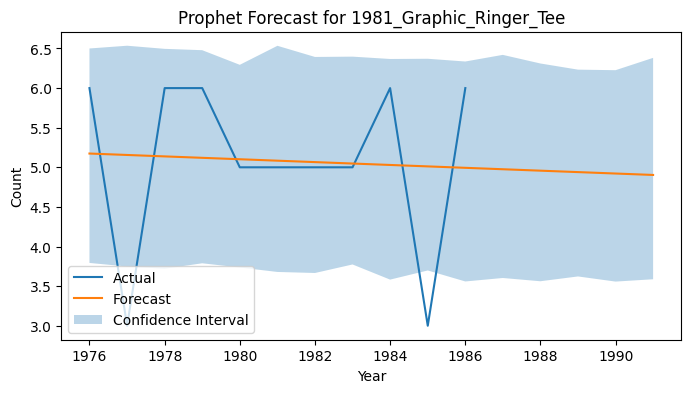

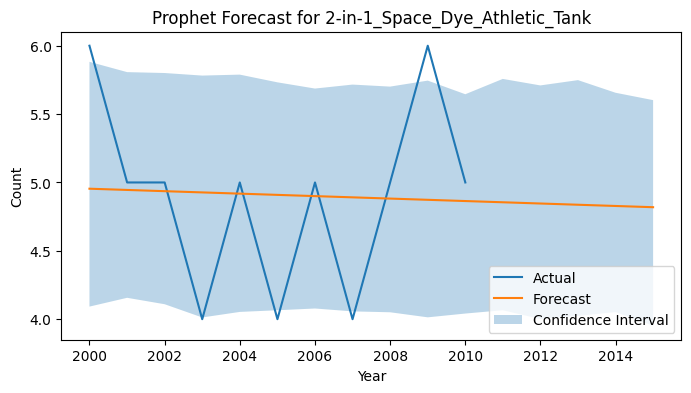

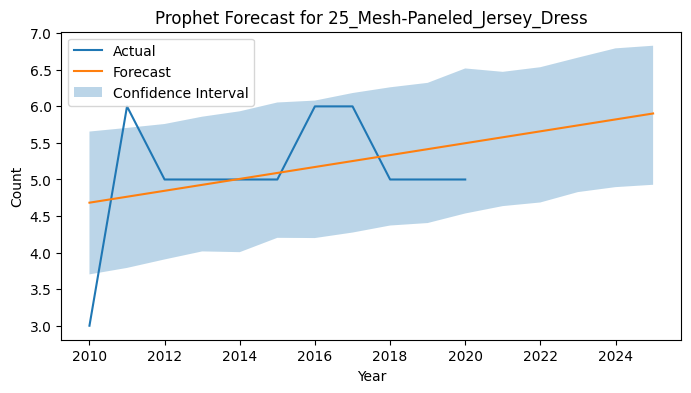

In [ ]:
import matplotlib.pyplot as plt

sample_cats = df['category'].unique()[:3]  # plot first 3 categories
for cat in sample_cats:
    sub = df[df['category'] == cat]
    pred = final_forecast[final_forecast['Category'] == cat]

    plt.figure(figsize=(8, 4))
    plt.plot(sub['ds'], sub['y'], label="Actual")
    plt.plot(pred['ds'], pred['yhat'], label="Forecast")
    plt.fill_between(pred['ds'], pred['yhat_lower'], pred['yhat_upper'], alpha=0.3, label="Confidence Interval")
    plt.title(f"Prophet Forecast for {cat}")
    plt.xlabel("Year")
    plt.ylabel("Count")
    plt.legend()
    plt.show()


In [ ]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from tqdm import tqdm
import warnings

warnings.filterwarnings("ignore")

# 1️⃣ Load your dataset
df = pd.read_csv("synthetic_time_series.csv")

# Clean and prepare
df.columns = df.columns.str.strip().str.lower()
df['ds'] = pd.to_datetime(df['ds'])
df['y'] = df['y'].astype(int)

print("✅ Data loaded:", df.shape)
print(df.head())

# 2️⃣ ARIMA forecasting per category
all_forecasts = []
skipped = []

categories = df['category'].unique()

for cat in tqdm(categories, desc="Running ARIMA per category"):
    sub = df[df['category'] == cat].sort_values('ds')

    # Skip if too few unique years
    if sub['ds'].nunique() < 3:
        skipped.append(f"{cat} (too few data points)")
        continue

    try:
        # Fit ARIMA model: (p,d,q) = (1,1,1) as a reasonable default
        model = ARIMA(sub['y'], order=(1, 1, 1))
        fitted_model = model.fit()

        # Forecast next 5 years
        forecast_steps = 5
        forecast_result = fitted_model.get_forecast(steps=forecast_steps)
        forecast_mean = forecast_result.predicted_mean
        conf_int = forecast_result.conf_int()

        # Create future year range
        last_year = sub['ds'].max().year
        future_years = pd.date_range(start=f"{last_year+1}", periods=forecast_steps, freq="Y")

        forecast_df = pd.DataFrame({
            'ds': future_years,
            'yhat': forecast_mean.values,
            'yhat_lower': conf_int.iloc[:, 0].values,
            'yhat_upper': conf_int.iloc[:, 1].values,
            'Category': cat
        })

        all_forecasts.append(forecast_df)

    except Exception as e:
        skipped.append(f"{cat} (error: {e})")

# 3️⃣ Combine all forecasts
if all_forecasts:
    final_forecast = pd.concat(all_forecasts, ignore_index=True)
    final_forecast.to_csv("category_arima_forecasts.csv", index=False)
    print("✅ Forecasts saved to 'category_arima_forecasts.csv'")
else:
    print("⚠️ No forecasts generated — check data quality or ARIMA settings.")

# 4️⃣ Summary
print(f"✅ Categories processed: {len(categories)}")
print(f"⚠️ Skipped: {len(skipped)}")
if skipped:
    print("Example skipped:", skipped[:10])


✅ Data loaded: (61589, 4)
                  category  year  y         ds
0  1981_Graphic_Ringer_Tee  1976  6 1976-01-01
1  1981_Graphic_Ringer_Tee  1977  3 1977-01-01
2  1981_Graphic_Ringer_Tee  1978  6 1978-01-01
3  1981_Graphic_Ringer_Tee  1979  6 1979-01-01
4  1981_Graphic_Ringer_Tee  1980  5 1980-01-01


Running ARIMA per category: 100%|██████████| 5599/5599 [08:00<00:00, 11.66it/s]


✅ Forecasts saved to 'category_arima_forecasts.csv'
✅ Categories processed: 5599
⚠️ Skipped: 0


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
)

# 1️⃣ Load all datasets
actual_df = pd.read_csv("synthetic_time_series.csv")
prophet_df = pd.read_csv("category_forecasts.csv")
arima_df = pd.read_csv("category_arima_forecasts.csv")

# 2️⃣ Clean and prepare
actual_df.columns = actual_df.columns.str.strip().str.lower()
prophet_df.columns = prophet_df.columns.str.strip().str.lower()
arima_df.columns = arima_df.columns.str.strip().str.lower()

actual_df['ds'] = pd.to_datetime(actual_df['ds'])
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])
arima_df['ds'] = pd.to_datetime(arima_df['ds'])

# Ensure column consistency
prophet_df.rename(columns={'category': 'Category'}, inplace=True)
arima_df.rename(columns={'category': 'Category'}, inplace=True)
actual_df.rename(columns={'category': 'Category'}, inplace=True)

# 3️⃣ Merge Prophet & ARIMA with Actuals
merged_prophet = pd.merge(actual_df, prophet_df, on=['Category', 'ds'], how='inner', suffixes=('_actual', '_prophet'))
merged_arima = pd.merge(actual_df, arima_df, on=['Category', 'ds'], how='inner', suffixes=('_actual', '_arima'))

# Skip if no overlap found
if merged_prophet.empty or merged_arima.empty:
    raise ValueError("⚠️ No overlapping years between actual and forecast data. Check 'ds' column alignment!")

# 4️⃣ Regression Metrics
def regression_metrics(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)
    return mae, rmse, r2

mae_p, rmse_p, r2_p = regression_metrics(merged_prophet['y_actual'], merged_prophet['yhat'])
mae_a, rmse_a, r2_a = regression_metrics(merged_arima['y_actual'], merged_arima['yhat'])

print("\n📊 **REGRESSION METRICS**")
print("Prophet:")
print(f"  MAE: {mae_p:.3f}, RMSE: {rmse_p:.3f}, R²: {r2_p:.3f}")
print("ARIMA:")
print(f"  MAE: {mae_a:.3f}, RMSE: {rmse_a:.3f}, R²: {r2_a:.3f}")

# 5️⃣ Classification-style metrics (based on direction: up/down)
def compute_direction_metrics(df, model_name):
    df = df.sort_values(['Category', 'ds'])
    df['actual_dir'] = df.groupby('Category')['y_actual'].diff().apply(lambda x: 1 if x > 0 else 0)
    df['pred_dir'] = df.groupby('Category')['yhat'].diff().apply(lambda x: 1 if x > 0 else 0)
    df = df.dropna(subset=['actual_dir', 'pred_dir'])

    y_true = df['actual_dir']
    y_pred = df['pred_dir']

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n🧩 {model_name} — CLASSIFICATION METRICS (Direction Up/Down):")
    print(f"  Accuracy:  {acc:.3f}")
    print(f"  Precision: {prec:.3f}")
    print(f"  Recall:    {rec:.3f}")
    print(f"  F1 Score:  {f1:.3f}")
    print(f"  Confusion Matrix:\n{cm}")

# Compute for both
compute_direction_metrics(merged_prophet, "Prophet")
compute_direction_metrics(merged_arima, "ARIMA")


ValueError: ⚠️ No overlapping years between actual and forecast data. Check 'ds' column alignment!